<a href="https://colab.research.google.com/github/samrat-rm/Brain-Cache/blob/main/LoanTap_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoanTap Logistic Regression


**(A Scaler Business case study)**

Date: 9 June 2026

### Context:

LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

- Personal Loan
- EMI Free Loan
- Personal Overdraft
- Advance Salary Loan


This case study will focus on the underwriting process behind Personal Loan only.



### Problem Statement:

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/samrat-rm/Brain-Cache/main/Business_case_study/Data/LoanTap.csv"
df = pd.read_csv(url)
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


## Understanding the data

In this section we try to understand the domain specific terms and metrics.

We understand each column , the meaning of each category and the high level trend in each column. This will be helpful during data cleaning, feature engiennering and EDA.




In [4]:
df.shape

(396030, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

### Categorical Data

In [6]:
df.select_dtypes(include='object').columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

Now, Lets understand each column and each column's descrition.

**Data dictionary:**


- term : The number of payments on the loan. Values are in months and can be either 36 or 60.
- grade : LoanTap assigned loan grade
- sub_grade : LoanTap assigned loan subgrade
- emp_title :The job title supplied by the Borrower when applying for the loan.
- emp_length : Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
- home_ownership : The home ownership status provided by the borrower during registration or obtained from the credit report.
- verification_status : Indicates if income was verified by LoanTap, not verified, or if the income source was verified
- issue_d : The month which the loan was funded
- loan_status : Current status of the loan - Target Variable
- purpose : A category provided by the borrower for the loan request.
- title : The loan title provided by the borrower
- earliest_cr_line :The month the borrower's earliest reported
- initial_list_status : The initial listing status of the loan. Possible values are – W, F
- application_type : Indicates whether the loan is an individual application or a joint application with two co-borrowers
- Address: Address of the individual

In [7]:
df['term'].value_counts()

,count
term,
36 months,302005
60 months,94025


- ~76% people chose 36 month term and the rest chose 60 month term.

Each of the 6 grade has 5 sub grades. Eg: A1 - A5 , B1 - B5...

In [8]:
print('Unique values and their order for `grade` column:')
print(df['grade'].sort_values().unique())

print('\nUnique values and their order for `sub_grade` column:')
print(df['sub_grade'].sort_values().unique())

Unique values and their order for `grade` column:
['A' 'B' 'C' 'D' 'E' 'F' 'G']

Unique values and their order for `sub_grade` column:
['A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4'
 'C5' 'D1' 'D2' 'D3' 'D4' 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3'
 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']


The `grade` column represents an internal credit rating assigned by LoanTap, where 'A' is the best (lowest risk) and 'G' is the worst (highest risk). Within each grade, `sub_grade` further refines this rating, with '1' being better than '5'. For example, A1 is superior to A5, and A is superior to B.

In [9]:
print(df['emp_title'].value_counts().head(20))
print(f'Number of unique employee titles: {df["emp_title"].nunique()}')

emp_title
Teacher                     4389
Manager                     4250
Registered Nurse            1856
RN                          1846
Supervisor                  1830
Sales                       1638
Project Manager             1505
Owner                       1410
Driver                      1339
Office Manager              1218
manager                     1145
Director                    1089
General Manager             1074
Engineer                     995
teacher                      962
driver                       882
Vice President               857
Operations Manager           763
Administrative Assistant     756
Accountant                   748
Name: count, dtype: int64
Number of unique employee titles: 173105


The `emp_title` column contains the job title provided by the borrower. With over 170,000 unique values, this column has very high cardinality, making it difficult to use directly in a machine learning model. However, it can be a valuable source for feature engineering.

Potential Feature Engineering Ideas:
- **Categorization**: Group similar job titles into broader categories (e.g., 'Teacher', 'Engineer', 'Medical Professional', 'Manager').
- **Keywords**: Extract keywords from job titles that might indicate seniority, industry, or specific skills.
- **Binary Features**: Create binary flags for certain high-frequency or high-impact job titles (e.g., `is_owner`, `is_doctor`).
- **Embedding**: For more advanced approaches, one could use text embeddings if a sufficient vocabulary of job titles is available.

For now, given its high cardinality, we will treat it as a column to be processed during feature engineering, rather than directly used as a categorical feature.

In [10]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,126041
2 years,35827
< 1 year,31725
3 years,31665
5 years,26495
1 year,25882
4 years,23952
6 years,20841
7 years,20819


- The emp_length column describes the borrower's employment length in years. The possible values range from 0 (meaning less than one year) to 10 (meaning ten or more years).
- Feature Engineerig: We can combine emp_years and job_title to extract or more confidently describe senior positions or skill level.

In [11]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,112
NONE,31
ANY,3


- OTHER: This category typically refers to housing situations that don't fit into the standard categories like 'MORTGAGE', 'RENT', or 'OWN'. It could include living with relatives without paying rent, living in employer-provided housing, or other less common arrangements.
- NONE: This usually means the borrower does not own a home and is not renting. They might be living rent-free with family or friends, or in a transitional living situation.
- ANY: This is a less common category, but it could imply a broad or unspecified form of ownership, or it might be a catch-all for various non-standard situations.

In [12]:
df['verification_status'].value_counts()

,count
verification_status,
Verified,139563
Source Verified,131385
Not Verified,125082


- 'Source Verified' in the verification_status column means that LoanTap has confirmed the borrower's income or other financial information directly with a third-party source. This could include contacting the borrower's employer, bank, or another official institution to verify the provided details.

In [13]:
df['issue_d'].agg(['min','max'])

,issue_d
min,Apr-2008
max,Sep-2016


- The LoanTap consists of 8 years of loan data.  

In [14]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


- Fully Paid: This indicates that the borrower has successfully repaid the loan in its entirety, including all principal and interest, according to the agreed-upon terms.

- Charged Off: This means that the lender (LoanTap) has deemed the loan uncollectible. It typically occurs when a borrower has failed to make payments for an extended period, and the lender has given up on recovering the debt through normal collection efforts.

In [15]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,234507
credit_card,83019
home_improvement,24030
other,21185
major_purchase,8790
small_business,5701
car,4697
medical,4196
moving,2854


- The majority of the loan applications are debt consolidation, almost 60% and 20% of applications are credit card payoff.
- This indicates that the features related to credit accounts and credit limit etc are important in the credit extension prediction.

In [16]:
df['title'].value_counts()[:20]

,count
title,
Debt consolidation,152472
Credit card refinancing,51487
Home improvement,15264
Other,12930
Debt Consolidation,11608
Major purchase,4769
Consolidation,3852
debt consolidation,3547
Business,2949


The title of the loa application given by the applicant. Its like a more extended feature of pupose of loan. It can be useful during advanced feature engineering.


In [17]:
df['earliest_cr_line'][:5]

,earliest_cr_line
0,Jun-1990
1,Jul-2004
2,Aug-2007
3,Sep-2006
4,Mar-1999


- The earliest_cr_line column represents the month and year the borrower's earliest reported credit line was opened.
- This can be used to understand the longevity of the credit history of the applicant.

In [18]:
df['initial_list_status'].value_counts()

,count
initial_list_status,
f,238066
w,157964


- **w** stands for Whole (or sometimes 'whole loan'). This means the loan was initially listed as a whole loan, typically sold to a single investor.
- **f** stands for Fractional (or 'fractional interest'). This means the loan was initially listed as a fractional interest, where parts of the loan were sold to multiple investors.

In [19]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,395319
JOINT,425
DIRECT_PAY,286


- INDIVIDUAL: This means a single borrower is applying for the loan and is solely responsible for its repayment.
- JOINT: This indicates that two or more individuals are applying for the loan together. Both applicants are typically co-borrowers and are jointly responsible for the loan's repayment.
- DIRECT_PAY: This type of application usually refers to a loan where the funds are disbursed directly to a third party (e.g., a credit card company for debt consolidation, or a vendor for a specific purchase) rather than directly to the borrower. It simplifies the payment process by sending the funds where they are intended to go.

**Difference between application_type and initial_list_status:**

- `application_type` describes who is applying for the loan and how the borrower(s) are structured (e.g., one person, multiple people sharing responsibility, or funds going directly to a third party).
- `initial_list_status` describes how the loan is initially offered or packaged to investors on a lending platform.

In [20]:
len(df['address'].unique())

393700

In [21]:
df['address'][9]

'3390 Luis Rue\r\nMauricestad, VA 00813'

We can extract parts of address into new feats like city, country and zip code during feature engineering.

### Numerical Data

In [22]:
df.select_dtypes(exclude='object').columns

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

**Data dictionary:**

- loan_amnt : The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- int_rate : Interest Rate on the loan
- installment : The monthly payment owed by the borrower if the loan originates.
- annual_inc : The self-reported annual income provided by the borrower during registration.
- dti : A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LoanTap loan, divided by the borrower’s self-reported monthly income.
- open_acc : The number of open credit lines in the borrower's credit file.
- pub_rec : Number of derogatory public records
- revol_bal : Total credit revolving balance
- revol_util : Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
- total_acc : The total number of credit lines currently in the borrower's credit file
- mort_acc : Number of mortgage accounts.
- pub_rec_bankruptcies : Number of public record bankruptcies

<Axes: >

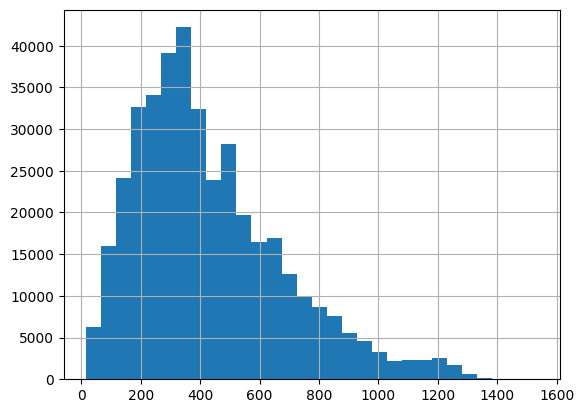

In [ ]:
df['installment'].hist(bins=30)

- Unimodal
- The data in concentrated around 150-400 with a peak around 370.
- Right skewed with a long tail as the installemnt ammount increases.
- The frequency dips off after 1000 which can be interpreted as outliars.

In [ ]:
df['dti'].describe()

The Debt-to-Income (DTI) ratio is a personal finance measure that compares how much money you earn to how much you owe each month. It's a key metric lenders use to assess your ability to manage monthly payments and repay debts. A lower DTI ratio generally indicates that you have more income available to cover your debts, making you a less risky borrower.

$$\text{DTI} = \left( \frac{\text{Total Monthly Debt Payments}}{\text{Gross Monthly Income}} \right) \times 100$$


> Note - Data dictionary: "excluding mortgage and the requested LoanTap loan"

In [ ]:
df['open_acc'].hist()

- Unimodal. Strong Right skewed. Concentrated on the 0-18 range.
- The long tail after 30 can be considered as outliars.

In [ ]:
df['pub_rec'].hist()

In [ ]:
df['pub_rec'].value_counts().head(5)

- Extreamly concentrated. Nearlt all values are between 0-10
- There are a few very large outliars.
- Unimodal and ~83% of data is 0.

In [ ]:
df['revol_bal'].describe()

- Extreme right skew, classic revolving-balance shape. Mean (15,844) > median, long tail of a few high-balance borrowers.
min = 0 is fine here (many people carry no revolving debt).

The `revol_bal` stands for Revolving Balance. This refers to the total outstanding balance that a borrower has across all their revolving credit accounts, such as credit cards and lines of credit. It represents the amount of money a borrower currently owes on their credit lines that they can continuously draw from and repay.

In [ ]:
df['revol_util'].describe()

`revolv_util` how much of your available revolving credit you're actually using, as a percentage.
Revolving credit = credit cards, lines of credit — limits you can borrow against repeatedly. If your cards total a 10,000 limit and you're carrying 3,000 in balance, your revol_util is 30%.

- Extreme right skew
- min = 0 is fine here (many people carry no revolving debt).
- Values above 100 are caused by fees compounding, interest, or the issuer allowing overage.

In [ ]:
df['total_acc'].describe()

- "Credit line" here = any credit account the borrower has ever had on file — not just active ones.
- So `total_acc` counts every account in their credit history: credit cards, auto loans, mortgages, student loans, store cards open or closed, all of it.
- Contrast with `open_acc`, which you also have: that's only the accounts currently open. So `total_acc` ≥ `open_acc` always (total includes the closed ones too).

In [ ]:
df['mort_acc'].value_counts().head(5)

- This is a niche feature which is most useful for loan applicants with mortage as the puprose of loan. It also plays a small factor in understanding the applicant's overall credit status.

In [ ]:
df['pub_rec_bankruptcies'].value_counts()

- Almost ~90% of people have no public record of bankruptcies.
- Intuitively this is a very important metric.

## Exploratory Data Analysis

1. Target analysis
2. Univariate Analysis for Numerical data

### Target Analysis


`loan_status` is our target variable.

In [ ]:
df['loan_status'].value_counts()

In [ ]:
df['loan_status'].value_counts().plot(kind='bar')

- 20% of the applicants have defaulted in our data.

Problem statement tells us to predict the loan defaulter. So, we choose class 1 as "Charged off".


**Target Metrics:**

- Recall = "of all real defaulters, how many did we catch?"
- Precision = "of everyone we flagged as defaulter, how many truly defaulted?"

- Accuracy metric is not useful since there is a 1:4 imabalance in our target classes.

###  Univariate Analysis for Numerical data

In [ ]:
df.select_dtypes(exclude='object').columns

#### Loan Amount

In [ ]:
df['loan_amnt'].describe()

In [ ]:
df['loan_amnt'].hist(bins=30)

In [ ]:
df.isna().sum()['loan_amnt']

- There is no nan or impossible values like 0.
- The loan amount has a mean of 14K and has a wide range of 500-40K

- The globally right-skewed, with local peaks at round amounts (10/15/20k) due to human preference for round figures.
- The 35k spike is the max. A pile-up near the maximum (40K) often means the value is capped.

**Hypothesis:**

Loan amount might have a strong relationship to the target. Probability of default, possibly accelerating at the extremes

#### Interest Rate

In [ ]:
df['int_rate'].isna().sum() , (df['int_rate'] == 0).sum()

In [ ]:
df['int_rate'].describe()

In [ ]:
df['int_rate'].hist(bins=15)

- Unimodal, Right skewed with a long tail as the itnerest rate increases.
- Most applicants are priced at 7–17%, meaning the portfolio is mostly lower-to-mid risk
- The interest rates above 25 can be considered as very high risk applicanrs. Since their high interest rate indicates their bad credit health.

**Hypothesis:**

Interest in the range 7-17 monotonic relation to target but interest that are on the extreme might drastically increases the change of default.

#### Debt-to-Income (DTI) ratio

In [ ]:
df['dti'].describe()

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['dti'], color='skyblue')
plt.title('DTI Boxplot (Showing Extreme Outliers)')
plt.xlabel('Debt-to-Income (DTI) Ratio')
plt.show()

DTI of 9999% is impossible (it'd mean debt payments 100× income). Systems often dump 9999 or -1 when the true value is missing. So treat it as a missing-value/data-quality issue, not a genuine extreme.

Lets ignore the extreme outliars and focus on the general trend of the dti.

In [ ]:
dti = df[df['dti'] < 175]['dti']

plt.figure(figsize=(8, 4))
sns.boxplot(x=dti, color='skyblue')
plt.title('DTI Boxplot (Showing Extreme Outliers)')
plt.xlabel('Debt-to-Income (DTI) Ratio')
plt.show()

In [ ]:
dti.hist(bins=30)

- The data is strongly concentrated between 0 and 35 with a peak at 15-20
- It's unimodal and roughly symmetric in the bulk, but there's a clear long right tail.
- The mean is 17 and 75% is ~23 but the max is 9999 suggesting big outliars.
- A dti above 100 means the applican't can never payoff the loan uisng the income which itself is a huge indicator of loan default.

Let's analyse the extreme `dti` scores.

In [ ]:
(df['dti'] == 0).sum()

In [ ]:
(df['dti'] > 50).sum()

Check for impossible data:

In [ ]:
(df['dti'] > 100).sum()

In [ ]:
df[df['dti'] > 200]['dti']

- DTI measures debt excluding mortgage and the requested LoanTap loan. So `dti = 0` just means: before this loan, they had no other monthly debt obligations.

- A DTI of above 1000 is impossible data. Values in the range are placeholder codes or unit errors (someone fed a raw balance instead of a ratio). These are data corruption.

- DTI benchmark:

  - Low DTI ($\le 36\%$): Good financial health. The borrower has plenty of income left over after paying bills.
  
  - High DTI ($\ge 50\%$): High risk. Most of the borrower's income goes toward paying off existing debt, making them highly susceptible to defaulting if they hit financial trouble.

**Hypothesis:**

High dti is directly related to high default chances. A dti of 50 or above exponentially increases the chances of default.

#### Annual income

Note:  Pandas switches to scientific notation when numbers span a wide range, because printing 8000000.00 next to 4500.00 in a table is ugly and hard to align. It's purely display; the underlying values are exact.

In [ ]:
df['annual_inc'].hist()

In [ ]:
df['annual_inc'].describe()

In [ ]:
annual_inc = df['annual_inc']

plt.figure(figsize=(8, 4))
sns.boxplot(x=annual_inc, color='skyblue')
plt.title('Annual Income Boxplot (Showing Extreme Outliers)')
plt.xlabel('Annual Income')
plt.show()

Let's ignore the extreme outliars to understand the trend.

In [ ]:
df['annual_inc'][df['annual_inc'] >= 1000000].shape

In [ ]:
df['annual_inc'][df['annual_inc'] >= 500000].shape

In [ ]:
annual_inc = df['annual_inc'][df['annual_inc'] < 1000000]

plt.figure(figsize=(8, 4))
sns.boxplot(x=annual_inc, color='skyblue')
plt.title('Annual Income Boxplot (Showing Extreme Outliers)')
plt.xlabel('Annual Income')
plt.show()


- The min annual income value is 0 and the max is ~8M
- The 75% value is 90,000 which compared to max ~8M suggests that the annual income data is right skewed and has many outliars.

In [ ]:
df['annual_inc'][df['annual_inc'] == 0].shape

In [ ]:
df[['annual_inc','dti','loan_status','loan_amnt']][df['annual_inc'] == 0]

`annual_inc = 0` is suspect, unlike `dti = 0`. A salaried-lending platform shouldn't be funding someone with literally zero income it contradicts their whole model. So it's likely either a data error or a borrower whose income wasn't reported/verified.

**Hypothesis:**

I expect higher annual income to associate with lower default rates, because higher earners have more cushion to cover payments. But the data is heavily skewed a 8M earner and a 200K earner both have repaying ability so the relationship maybe weak and not linear.

### Installment

In [ ]:
df['installment'].hist(bins=30)

### To Dos:

- [ ] Change the object to category dtype and `issue_d`,`earliest_cr_line` to datetime type.
- [ ] Look into feature eng of 'title'
- [ ] We can extract parts of address into new feats like city, country and zip code during feature engineering.
 -[ ] Check the trend b/w interest rate, loan amount
 - [ ] installment vs loan anount vs loan period
 - Annual income has 0 data
 - Compare total_acc and open_acc
 - Use mortgage , credit default, open acc metrics to find trends. MAybe new good features from these.
 - Which we have to resolve in the feature engineering section.
 - int_rate and grade both encode risk, they'll be correlated with each other

- dti outliars > 1000
- annual inc 0
-

High-level EDA roadmap. We'll go through each one by one:

1. **Target analysis** — `loan_status` distribution and imbalance. (The anchor; everything references back to it.)

2. **Univariate — numeric** — distributions of the continuous vars (loan_amnt, int_rate, installment, annual_inc, dti, revol_bal, revol_util, etc.). Shape, skew, outliers.

3. **Univariate — categorical** — counts of grade, sub_grade, home_ownership, purpose, verification_status, term, etc.

4. **Bivariate — feature vs target** — how each predictor relates to default. This is the heart of it: does grade predict default? Does term? Does int_rate differ for defaulters? (count plots split by target, box plots by target.)

5. **Correlation** — heatmap among numerics; spot multicollinearity (you already suspect loan_amnt ↔ installment).

6. **Insights summary** — pull the findings into a few crisp statements, and answer the questionnaire items that EDA covers.

We do them in this order because each builds context for the next.

Start with **step 1**: plot `loan_status` and state the split. Before you plot — what kind of plot fits a single categorical target, and which loan_status value will be your "positive" class for modeling?